# Multistory Channel Charting

## Set Up Environment

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
import numpy as np

from scenario2_utils import (
    DEFAULT_SEED,
    affine_transform_channel_chart,
    build_csi_features,
    fit_channel_chart,
    floor_sample_indices,
    load_dataset_artifacts,
    load_estimated_floor_indices,
    load_npz_array_dict,
    plot_cdf,
    plot_cdf_2d,
    plot_scene_overview,
    plot_spatial_colorized_positions,
    reorder_by_floor,
    save_npz_array_dict,
    set_random_seeds,
 )

set_random_seeds(DEFAULT_SEED, tf_module=tf)

E0000 00:00:1776284775.072266    1635 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776284775.079354    1635 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776284775.097174    1635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284775.097447    1635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284775.097449    1635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284775.097451    1635 computation_placer.cc:177] computation placer already registered. Please check linka

## Load Data, Features, and Floor-Wise Inputs

In [2]:
dataset = load_dataset_artifacts(include_geometry=True)
csi_freq_domain_train = dataset.csi_freq_domain_train
groundtruth_positions_train = dataset.groundtruth_positions_train
array_positions_3D = dataset.array_positions_3d
center_positions_3D = dataset.center_positions_3d
floor_nr = dataset.floor_nr
ue_heights = dataset.ue_heights
estimated_floor_indices = load_estimated_floor_indices()
sample_indices_by_floor = {
    floor_index: floor_sample_indices(estimated_floor_indices, floor_index)
    for floor_index in range(floor_nr)
}
dissimilarity_matrix_geodesic_by_floor = load_npz_array_dict("results/dissimilarity_matrix_geodesic_by_floor.npz")

print("Shape of csi_freq_domain_train: ", csi_freq_domain_train.shape)
print("Shape of groundtruth_positions_train: ", groundtruth_positions_train.shape)
print("Shape of array_positions_3D: ", array_positions_3D.shape)
print("Shape of center_positions_3D: ", center_positions_3D.shape)
print("floor_nr: ", floor_nr)
print(ue_heights)
print("Shape of estimated floor: ", estimated_floor_indices.shape)

Shape of csi_freq_domain_train:  (5000, 5, 4, 2, 4, 64)
Shape of groundtruth_positions_train:  (5000, 3)
Shape of array_positions_3D:  (5, 4, 3)
Shape of center_positions_3D:  (5, 3)
floor_nr:  5
[ 1.5   5.65  9.8  13.95 18.1 ]
Shape of estimated floor:  (5000,)


### Build CSI Features

In [3]:
_, _, csi_features = build_csi_features(csi_freq_domain_train)

print(csi_features.shape)

(5000, 20, 16, 16, 2)


## Optional: Visualize Dataset

In [4]:
SHOW_DATASET_PREVIEW = False

if SHOW_DATASET_PREVIEW:
    plot_scene_overview(
        groundtruth_positions_train,
        array_positions_3D,
        center_positions_3D,
    )

## Train Floor-Wise Channel Charts

In [5]:
channel_chart_positions_by_floor = {}

for floor_index in range(floor_nr):
    print("floor index: {}".format(floor_index))

    sample_indices = sample_indices_by_floor[floor_index]
    channel_chart_positions = fit_channel_chart(
        csi_features[sample_indices],
        dissimilarity_matrix_geodesic_by_floor[floor_index],
        embedding_dim=2,
        seed_a=DEFAULT_SEED + 2 * floor_index,
        seed_b=DEFAULT_SEED + 2 * floor_index + 1,
    )
    channel_chart_positions = np.insert(channel_chart_positions, 2, ue_heights[floor_index], axis=1)
    channel_chart_positions_by_floor[floor_index] = channel_chart_positions

floor index: 0


I0000 00:00:1776284812.196861    1635 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22290 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:c1:00.0, compute capability: 8.9



Training Session  1 
Batch Size:  400 
Learning rate:  0.005


I0000 00:00:1776284817.577407    1731 service.cc:152] XLA service 0x7fbfac014d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776284817.577447    1731 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
I0000 00:00:1776284818.299342    1731 cuda_dnn.cc:529] Loaded cuDNN version 90300


 15/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 21.7479

I0000 00:00:1776284820.806120    1731 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 4.6435

Training Session  2 
Batch Size:  800 
Learning rate:  0.002
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.4348

Training Session  3 
Batch Size:  1200 
Learning rate:  0.001
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 1.3328

Training Session  4 
Batch Size:  2000 
Learning rate:  0.001
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 1.2889

Training Session  5 
Batch Size:  3000 
Learning rate:  0.0005
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 1.2784

Training Session  6 
Batch Size:  3000 
Learning rate:  0.0001
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.2696

Training Session  7 
Batch Size:  4000 
Learning rate:  5e-05
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 1.2719

Training Session  8 
Batch Size:  5000 
Learning rate:  1e-05
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 1.2646
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
floor index: 1

Training Session  1 
Batch Size:  400 
Learning rate:

### Save Floor-Wise Chart Coordinates

In [6]:
save_npz_array_dict(
    "results/channel_chart_positions_by_floor.npz",
    channel_chart_positions_by_floor,
 )

## Evaluate and Visualize Results

### Evaluation Note

This evaluation measures the full multistory method: first classify the floor, then localize within that floor using a floor-wise 2D affine alignment, and finally reinsert the known floor height.

Because floor classification is an explicit part of the method, floor assignment errors are intentionally included in the final localization error.

This makes the evaluation method-faithful, but not strictly protocol-identical to the baseline notebook, which evaluates one globally aligned 3D chart.

### Reconstruct Global Coordinates

### Apply Floor-Wise 2D Alignment
Align each floor-specific chart only in the horizontal plane, then reinsert the known floor height before computing the final metrics and plots.

In [7]:
# Transform floor-wise channel chart positions using only x-y coordinates, then reinsert the classified floor height
channel_chart_positions_transformed_by_floor = {}

for floor_index in range(floor_nr):
    print("floor index: {}".format(floor_index))

    sample_indices = sample_indices_by_floor[floor_index]
    channel_chart_positions_xy = affine_transform_channel_chart(
        groundtruth_positions_train[sample_indices, :2],
        channel_chart_positions_by_floor[floor_index][:, :2],
    )

    channel_chart_positions = np.insert(channel_chart_positions_xy, 2, ue_heights[floor_index], axis=1)
    channel_chart_positions_transformed_by_floor[floor_index] = channel_chart_positions

floor index: 0
floor index: 1
floor index: 2
floor index: 3
floor index: 4


In [8]:
channel_chart_positions_transformed = np.concatenate(
    [channel_chart_positions_transformed_by_floor[floor_index] for floor_index in range(floor_nr)],
    axis=0,
 )

groundtruth_positions_reordered = reorder_by_floor(
    groundtruth_positions_train,
    estimated_floor_indices,
    floor_nr,
 )

print(channel_chart_positions_transformed.shape)
print(groundtruth_positions_reordered.shape)

(5000, 3)
(5000, 3)


### Visualize and Score the Final Reconstruction

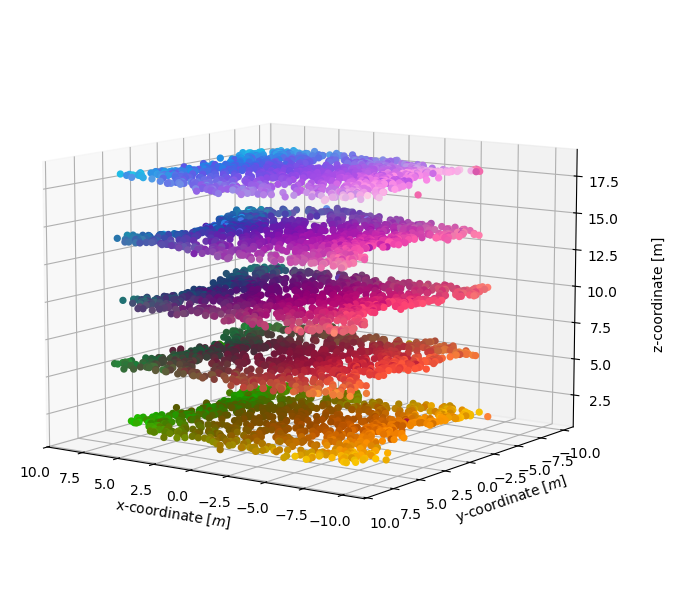

In [9]:
plot_spatial_colorized_positions(
    channel_chart_positions_transformed,
    groundtruth_positions_reordered,
    save_path="results/cc_positions_transformed_2d_affine.png",
 )

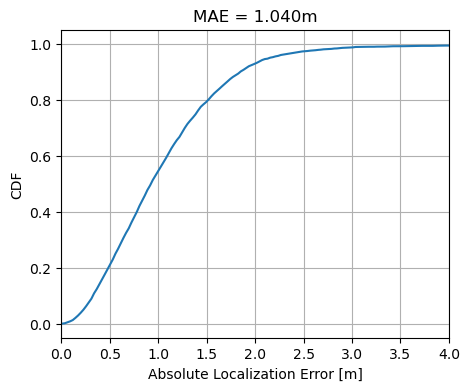

In [10]:
plot_cdf(channel_chart_positions_transformed, groundtruth_positions_reordered, title = "Training Set")

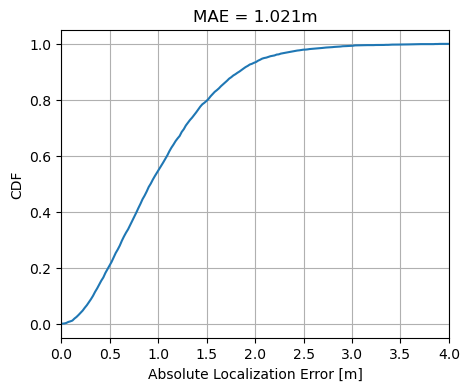

In [11]:
plot_cdf_2d(channel_chart_positions_transformed[:, :2], groundtruth_positions_reordered[:, :2], title="Training Set - 2D errors")